In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyproj import Transformer

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

RANDOM_STATE = 42


In [56]:
df = pd.read_parquet('../preprocessing_output_v4.parquet')
print(df.shape)
df.head(3)


(1000000, 98)


,Unnamed: 0,city_slug,description,title,rent_mode,rent_value,price_mode,price_value,credit_mode,credit_value,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,location_latitude,location_longitude,is_negotiable,is_transformable,is_full_mortgage,equivalent_full_credit,weekend_price_ratio,special_day_price_ratio,is_rent_credit_convertible,allows_single_tenant,log_price_value,log_credit_value,log_rent_value,log_equivalent_full_credit,days_since_start,month,month_sin,month_cos,city_freq_enc,deal_type_other,deal_type_rent,deal_type_sell,deal_type_temporary_rent,property_category_apartment,property_category_industry,property_category_office,property_category_other,property_category_plot_land,property_category_shop,property_category_villa,user_type_شخصی,user_type_مشاور املاک,PreP_has_pool,PreP_has_jacuzzi,PreP_has_sauna,PreP_has_balcony,PreP_has_elevator,PreP_has_parking,PreP_has_security_guard,PreP_has_barbecue,PreP_has_warehouse,PreP_has_warm_water_provider,PreP_has_heating_system,PreP_has_restroom,PreP_floor_material,PreP_building_direction,PreP_has_cooling_system,has_utilities,has_suana_jacuzzi,building_size_was_missing,land_size_was_missing,floor_was_missing,rooms_count_was_missing,total_floors_count_was_missing,unit_per_floor_was_missing,construction_year_was_missing,building_age,is_rebuilt_was_missing,deed_type_was_missing,has_business_deed_was_missing
0,0,karaj,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,<NA>,NaN,<NA>,NaN,<NA>,NaN,195.0,500.0,unknown,-1,2.0,3.0,4.0,2,NaN,NaN,NaN,NaN,1395.0,-1,None,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.811684,50.936600,False,False,False,NaN,2.333333,2333.333333,0,0,NaN,NaN,NaN,NaN,1674,8,-0.866025,-0.500000,49367,0,0,0,1,0,0,0,0,0,0,1,0,1,True,None,None,None,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,True,None,0,1,1,0,1,1,1,9.0,1,1,1
1,1,tehran,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,<NA>,NaN,مقطوع,8.500000e+09,<NA>,NaN,195.0,60.0,unknown,-1,3.0,1.0,4.0,2,NaN,True,True,True,1384.0,-1,None,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.773281,51.442539,False,False,False,NaN,NaN,NaN,0,0,22.863332,NaN,NaN,NaN,1582,5,0.500000,-0.866025,190904,0,0,1,0,1,0,0,0,0,0,0,0,1,None,None,None,None,True,True,None,None,True,NaN,NaN,NaN,NaN,NaN,NaN,True,None,0,1,0,0,1,1,0,20.0,1,1,1
2,2,tehran,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,<NA>,NaN,مقطوع,750000000.0,195.0,132.0,unknown,-1,3.0,3.0,4.0,2,NaN,True,True,True,1401.0,-1,None,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,False,False,False,1.616667e+09,NaN,NaN,0,0,NaN,20.435584,17.073607,21.203632,1735,10,-0.866025,0.500000,190904,0,1,0,0,1,0,0,0,0,0,0,0,0,None,None,None,None,True,True,None,None,True,NaN,NaN,NaN,NaN,NaN,NaN,True,None,0,1,0,0,1,1,0,3.0,0,1,1


In [58]:
key_cols = ["city_slug", "location_latitude", "location_longitude",
    "price_value", "credit_value", "rent_value",
    "log_price_value", "log_equivalent_full_credit", "equivalent_full_credit",
    "building_size", "land_size", "rooms_count",
    "PreP_has_elevator", "PreP_has_parking",
    "deal_type_sell", "deal_type_rent", "deal_type_temporary_rent", "deal_type_other",]
missing_report = df[key_cols].isna().mean().sort_values(ascending=False) * 100
missing_report.to_frame("missing percentage")

,missing percentage
log_equivalent_full_credit,65.2288
equivalent_full_credit,65.2288
credit_value,65.1014
rent_value,64.9167
PreP_has_elevator,45.2592
log_price_value,44.4840
price_value,44.4840
PreP_has_parking,25.6642
location_latitude,0.0002
city_slug,0.0002


In [59]:
LAT_MIN, LAT_MAX = 25.0, 40.0
LON_MIN, LON_MAX = 44.0, 64.0
coord_missing = df["location_latitude"].isna() | df["location_longitude"].isna()
coord_out_of_range = (~df["location_latitude"].between(LAT_MIN, LAT_MAX) |~df["location_longitude"].between(LON_MIN, LON_MAX))
invalid_coord = coord_missing | coord_out_of_range
df["has_valid_coord"] = ~invalid_coord
df_geo = df.loc[df["has_valid_coord"]].copy()
print(df.shape)

(1000000, 99)


UTM converts latitude/longitude into metric coordinates, making distance calculations more suitable for clustering algorithms such as K-Means and DBSCAN. Since Iran spans multiple UTM zones, using each point’s natural zone can create inconsistent coordinate systems. Therefore, all points are projected using a single UTM zone to keep the coordinates comparable across the country, at the cost of some distortion for locations far from the selected zone.

In [60]:
def utm_zone_number(lon):
    return int(np.floor((lon + 180) / 6) + 1)
df_geo["utm_zone_natural"] = df_geo["location_longitude"].apply(utm_zone_number)
zone_counts = df_geo["utm_zone_natural"].value_counts().sort_index()
print(zone_counts)
REFERENCE_ZONE = int(df_geo["utm_zone_natural"].mode().iloc[0])
pct_outside_ref = (df_geo["utm_zone_natural"] != REFERENCE_ZONE).mean() * 100
print(f"refrence zone {REFERENCE_ZONE}N (EPSG:326{REFERENCE_ZONE:02d})")
print(f"The percentage of different zones wchich causes distortion: {pct_outside_ref}%")

utm_zone_natural
38     90908
39    735733
40    159372
41     13985
Name: count, dtype: int64
refrence zone 39N (EPSG:32639)
The percentage of different zones wchich causes distortion: 26.426552853105704%


In [61]:
transformer = Transformer.from_crs("EPSG:4326", f"EPSG:326{REFERENCE_ZONE:02d}", always_xy=True)
easting, northing = transformer.transform(df_geo["location_longitude"].values, df_geo["location_latitude"].values)
df_geo["utm_easting"] = easting
df_geo["utm_northing"] = northing
df_geo["utm_zone"] = REFERENCE_ZONE  
df_geo[["city_slug", "location_latitude", "location_longitude","utm_zone_natural", "utm_easting", "utm_northing"]].sample(5, random_state=RANDOM_STATE)

,city_slug,location_latitude,location_longitude,utm_zone_natural,utm_easting,utm_northing
987231,tehran,35.705635,51.318630,39,5.288238e+05,3.951347e+06
79954,urmia,37.514000,45.050632,38,-2.601236e+04,4.168559e+06
567131,mashhad,36.373280,59.475685,40,1.261102e+06,4.058879e+06
500892,qom,34.642002,50.912352,39,4.919673e+05,3.833347e+06
55399,behbahan,30.623905,50.287186,39,4.316840e+05,3.388139e+06


Feature Engineering & Data Normalization
Categorical Flattening: Convert One-Hot encoded columns into single categorical labels (deal_type_cat, property_category_cat).
Within-Group Standardization: Apply Z-score normalization to log-transformed prices per deal_type. This mitigates scale bias between sale vs. rent models and ensures market-relative valuation.
Amenity Indexing: Consolidate binary amenities (elevator, parking) into a normalized [0, 1] score.
Feature Vector Assembly: Finalize the 7-dimensional input matrix (CLUSTER_FEATURES) for clustering algorithms.

In [62]:
deal_type_cols = ["deal_type_sell", "deal_type_rent", "deal_type_temporary_rent", "deal_type_other"]
df_geo["deal_type_cat"] = df_geo[deal_type_cols].idxmax(axis=1).str.replace("deal_type_", "", regex=False)
prop_cat_cols = [c for c in df_geo.columns if c.startswith("property_category_")]
if prop_cat_cols:
    df_geo["property_category_cat"] = (df_geo[prop_cat_cols].idxmax(axis=1).str.replace("property_category_", ""))

df_geo["unified_price_log"] = np.where(df_geo["deal_type_sell"] == 1, df_geo["log_price_value"], df_geo["log_equivalent_full_credit"])

grp = df_geo.groupby("deal_type_cat")["unified_price_log"]
grp_mean = grp.transform("mean")
grp_std = grp.transform("std").replace(0, np.nan)  
df_geo["price_position_z"] = (df_geo["unified_price_log"] - grp_mean) / grp_std

global_z = (df_geo["unified_price_log"] - df_geo["unified_price_log"].mean()) / df_geo["unified_price_log"].std()
df_geo["price_position_z"] = df_geo["price_position_z"].fillna(global_z)
df_geo["is_sale"] = pd.to_numeric(df_geo["deal_type_sell"], errors="coerce").astype(float)
amenity_cols = ["PreP_has_elevator", "PreP_has_parking"]
df_geo["amenity_score"] = (df_geo[amenity_cols].apply(pd.to_numeric, errors="coerce").fillna(0).mean(axis=1))

CLUSTER_FEATURES = ["price_position_z",
    "is_sale",
    "building_size",
    "rooms_count",
    "utm_easting",
    "utm_northing",
    "amenity_score",]
df_cluster = df_geo[CLUSTER_FEATURES].copy()
print("CLUSTER_FEATURES missings:")
print(df_cluster.isna().sum())
df_cluster.describe()

CLUSTER_FEATURES missings:
price_position_z    98363
is_sale                 0
building_size           0
rooms_count             0
utm_easting             0
utm_northing            0
amenity_score           0
dtype: int64


,price_position_z,is_sale,building_size,rooms_count,utm_easting,utm_northing,amenity_score
count,9.016350e+05,999998.000000,9.999980e+05,999998.000000,9.999980e+05,9.999980e+05,999998.000000
mean,3.811690e-16,0.597569,4.355612e+03,1.837495,5.729609e+05,3.851223e+06,0.478229
std,9.999983e-01,0.490388,1.353665e+05,0.832695,3.138706e+05,2.881856e+05,0.422676
min,-1.465514e+01,0.000000,1.000000e+00,0.000000,-1.651659e+05,2.784766e+06,0.000000
25%,-5.551337e-01,0.000000,7.500000e+01,1.000000,4.266692e+05,3.753324e+06,0.000000
50%,-3.228770e-02,1.000000,1.030000e+02,2.000000,5.322718e+05,3.952749e+06,0.500000
75%,5.641949e-01,1.000000,1.620000e+02,2.000000,6.132436e+05,4.045540e+06,1.000000
max,6.554142e+00,1.000000,1.000000e+07,4.000000,1.682020e+06,4.408207e+06,1.000000


### Missing Value Imputation Strategy
- **Listwise Deletion:** Columns with $< 5\%$ missingness are handled via `dropna` to minimize synthetic noise while maintaining data integrity.
- **Hierarchical Conditional Imputation:** Remaining missing values are resolved in two stages to preserve local market variances:
    1. **City-Category Median:** Primary imputation based on grouped `(city_slug, property_category_cat)` medians, capturing specific localized market characteristics.
    2. **Global Category Fallback:** Secondary imputation based on `property_category_cat` to ensure full coverage for segments lacking sufficient city-specific data.


In [63]:
missing_pct = df_cluster.isna().mean() * 100
low_missing = missing_pct[(missing_pct > 0) & (missing_pct < 5)].index
df_cluster = df_cluster.dropna(subset=low_missing)
df_geo = df_geo.loc[df_cluster.index]
missing_cols = df_cluster.columns[df_cluster.isna().any()]
for col in missing_cols:
    median_city_cat = df_cluster.groupby([df_geo["city_slug"], df_geo["property_category_cat"]])[col].transform("median")
    df_cluster[col] = df_cluster[col].fillna(median_city_cat)
    median_cat = df_cluster.groupby(df_geo["property_category_cat"])[col].transform("median")
    df_cluster[col] = df_cluster[col].fillna(median_cat)

### Outlier Handling via IQR Winsorization (Tukey's Method)
- **Target Features:** `price_position_z`, `building_size`, and `rooms_count`.
- **Methodology:** Winsorization (capping) using the interquartile range ($IQR = Q_3 - Q_1$) with a threshold multiplier of $k = 1.5$:
  $$\text{Lower Bound} = Q_1 - 1.5 \times IQR, \quad \text{Upper Bound} = Q_3 + 1.5 \times IQR$$
- **Rationale:** Instead of truncating rows (which discards valuable data points), extreme outliers are clipped to the calculated bounds. This stabilizes feature variances and mitigates distortion during distance-based clustering.



In [64]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr
outlier_cols = ["price_position_z", "building_size", "rooms_count"]
outlier_report = {}
for col in outlier_cols:
    low, high = iqr_bounds(df_cluster[col])
    n_out = ((df_cluster[col] < low) | (df_cluster[col] > high)).sum()
    outlier_report[col] = {"lower": low, "upper": high, "n_outliers": int(n_out)}
    df_cluster[col] = df_cluster[col].clip(lower=low, upper=high)
pd.DataFrame(outlier_report).T

,lower,upper,n_outliers
price_position_z,-2.234127,2.243188,34639.0
building_size,-55.500000,292.500000,118483.0
rooms_count,-0.500000,3.500000,21370.0


### Post-Transformation Distribution Analysis
- **Visualization:** Grid histogram plots (`histplot`) to inspect the feature distributions for `price_position_z`, `building_size`, and `rooms_count` after outlier clipping.
- **Objective:** 
    - Verify the effect of IQR-based Winsorization on data spread.
    - Check for unnatural density spikes at the clipping boundaries.
    - Confirm whether feature scaling (e.g., Z-score standardization) aligns with expected normal distributions for clustering algorithms.
- **Interpretation:** Note that `rooms_count` being discrete may exhibit "spiky" distributions, while continuous variables like `building_size` are expected to show reduced variance without losing the underlying distribution shape.


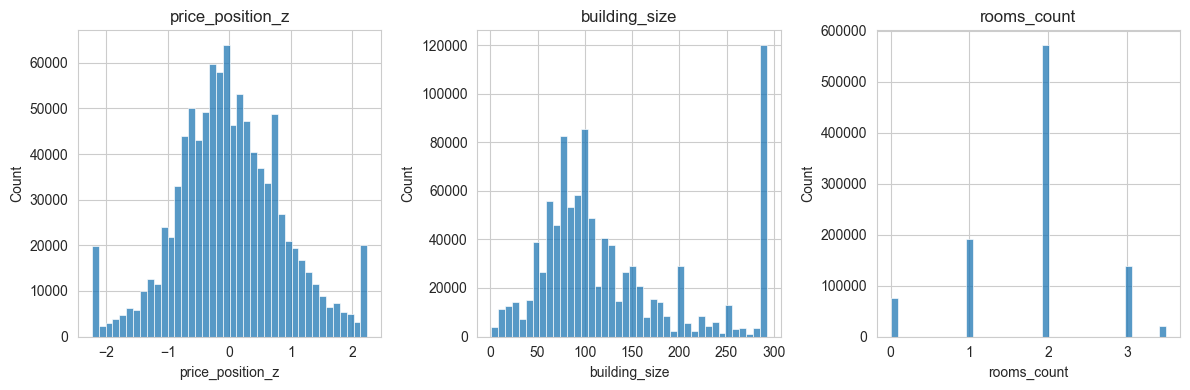

In [65]:
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(4 * len(outlier_cols), 4))
for ax, col in zip(axes, outlier_cols):
    sns.histplot(df_cluster[col], bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Feature Standardization (Z-Score Scaling)
- **Methodology:** Application of `StandardScaler` to all features designated for clustering (`CLUSTER_FEATURES`).
- **Mathematical Transformation:** Centers each feature to a zero mean and scales to unit variance:
  $$z = \frac{x - \mu}{\sigma}$$
- **Objective:** Eliminates arbitrary scale disparities (e.g., coordinates spanning $10^5$ meters in UTM vs. discrete counts like `rooms_count`), ensuring Euclidean distance metrics treat each feature's variance proportionally in downstream clustering tasks.
- **Verification:** Inspection via `.describe()` confirms $\mu \approx 0.00$ and $\sigma \approx 1.00$ across all transformed dimensions.


In [66]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[CLUSTER_FEATURES])

df_scaled = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES, index=df_cluster.index)
df_scaled.describe().round(2)

,price_position_z,is_sale,building_size,rooms_count,utm_easting,utm_northing,amenity_score
count,999998.00,999998.00,999998.00,999998.00,999998.00,999998.00,999998.00
mean,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.55,-1.22,-1.63,-2.26,-2.35,-3.70,-1.13
25%,-0.64,-1.22,-0.69,-1.02,-0.47,-0.34,-1.13
50%,-0.04,0.82,-0.34,0.21,-0.13,0.35,0.05
75%,0.64,0.82,0.41,0.21,0.13,0.67,1.23
max,2.55,0.82,2.07,2.07,3.53,1.93,1.23


### Final Dataset Packaging & Metadata Export
- **Index & Identifier Synchronization:** Retains the native ad identifier (`ad_id`) mapped directly to the original Divar dataset to enable seamless downstream relational joins.
- **Dual-Representation Output:** 
  - `_raw`: Preserves physical, interpretable values (e.g., actual square meters, log-price ratios) for post-clustering profiling and centroid interpretation.
  - `_scaled`: Provides zero-mean, unit-variance standardized features ready for direct consumption by distance-based clustering models.
- **Metadata Retention:** Preserves critical contextual dimensions (`city_slug`, `deal_type_cat`, `property_category_cat`, and `utm_zone`) for stratified cluster evaluation.
- **Artifact Serialization:** 
  - `clustering_input_clean.csv`: Cleaned, imputed, and scaled dataset.
  - `scaler.pkl`: Serialized `StandardScaler` object for inverse-transforming cluster centroids.
  - `feature_documentation.md`: Reproducibility manifest detailing all data pipelines and assumptions.



In [67]:
import pickle
if "Unnamed: 0" in df.columns:
    df_geo["ad_id"] = df.loc[df_geo.index, "Unnamed: 0"]
else:
    df_geo["ad_id"] = df_geo.index
output_df = df_geo.loc[df_cluster.index, ["ad_id", "city_slug", "deal_type_cat", "utm_zone", "property_category_cat"]].copy()
output_df = output_df.join(df_cluster[CLUSTER_FEATURES].add_suffix("_raw"))
output_df = output_df.join(df_scaled.add_suffix("_scaled"))
output_df.to_parquet("clustering_input_clean.parquet", engine="pyarrow", compression="snappy", index=False)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print(" ابعاد نهایی:", output_df.shape)
output_df.head()


 ابعاد نهایی: (999998, 19)


,ad_id,city_slug,deal_type_cat,utm_zone,property_category_cat,price_position_z_raw,is_sale_raw,building_size_raw,rooms_count_raw,utm_easting_raw,utm_northing_raw,amenity_score_raw,price_position_z_scaled,is_sale_scaled,building_size_scaled,rooms_count_scaled,utm_easting_scaled,utm_northing_scaled,amenity_score_scaled
0,0,karaj,temporary_rent,39,villa,0.256750,0.0,292.5,3.0,4.942723e+05,3.963064e+06,0.0,0.288886,-1.218564,2.070845,1.452489,-0.250704,0.388086,-1.131432
1,1,tehran,sell,39,apartment,0.845426,1.0,60.0,1.0,5.399990e+05,3.958893e+06,1.0,0.960003,0.820638,-0.884402,-1.023646,-0.105017,0.373613,1.234447
2,2,tehran,rent,39,apartment,1.009912,0.0,132.0,3.0,5.337844e+05,3.951168e+06,1.0,1.147523,-1.218564,0.030771,1.452489,-0.124817,0.346808,1.234447
3,3,tehran,rent,39,office,1.840001,0.0,90.0,1.0,5.385443e+05,3.960860e+06,1.0,2.093860,-1.218564,-0.503080,-1.023646,-0.109652,0.380438,1.234447
4,4,mashhad,sell,39,apartment,0.529831,1.0,115.0,2.0,1.273229e+06,4.048566e+06,1.0,0.600210,0.820638,-0.185312,0.214421,2.231074,0.684778,1.234447
